In [1]:
import pandas as pd
data=pd.read_csv("BankWages.csv")
print(data)

     rownames     job  education  gender minority
0           1  manage         15    male       no
1           2   admin         16    male       no
2           3   admin         12  female       no
3           4   admin          8  female       no
4           5   admin         15    male       no
..        ...     ...        ...     ...      ...
469       470   admin         12    male      yes
470       471   admin         15    male      yes
471       472   admin         15    male       no
472       473   admin         12  female       no
473       474   admin         12  female       no

[474 rows x 5 columns]


In [2]:
data.isnull().sum()

,0
rownames,0
job,0
education,0
gender,0
minority,0


In [3]:
from sklearn.preprocessing import LabelEncoder
b=LabelEncoder()
data["job"]=b.fit_transform(data["job"])
data["gender"]=b.fit_transform(data["gender"])
data["minority"]=b.fit_transform(data["minority"])
print(data)

     rownames  job  education  gender  minority
0           1    2         15       1         0
1           2    0         16       1         0
2           3    0         12       0         0
3           4    0          8       0         0
4           5    0         15       1         0
..        ...  ...        ...     ...       ...
469       470    0         12       1         1
470       471    0         15       1         1
471       472    0         15       1         0
472       473    0         12       0         0
473       474    0         12       0         0

[474 rows x 5 columns]


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   rownames   474 non-null    int64
 1   job        474 non-null    int64
 2   education  474 non-null    int64
 3   gender     474 non-null    int64
 4   minority   474 non-null    int64
dtypes: int64(5)
memory usage: 18.6 KB


In [5]:
data.describe()

,rownames,job,education,gender,minority
count,474.000000,474.000000,474.000000,474.000000,474.000000
mean,237.500000,0.411392,13.491561,0.544304,0.219409
std,136.976275,0.773201,2.884846,0.498559,0.414284
min,1.000000,0.000000,8.000000,0.000000,0.000000
25%,119.250000,0.000000,12.000000,0.000000,0.000000
50%,237.500000,0.000000,12.000000,1.000000,0.000000
75%,355.750000,0.000000,15.000000,1.000000,0.000000
max,474.000000,2.000000,21.000000,1.000000,1.000000


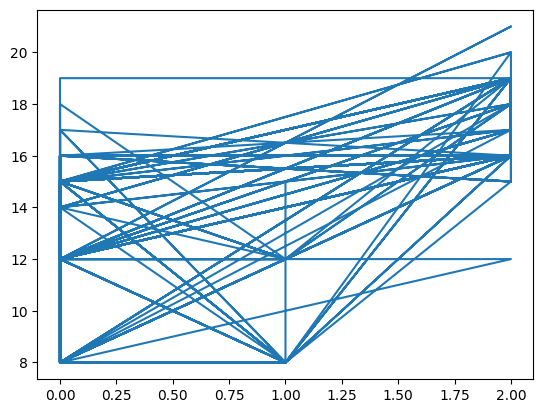

In [6]:
from matplotlib import pyplot as plt
plt.plot(data["job"],data["education"])

<BarContainer object of 474 artists>

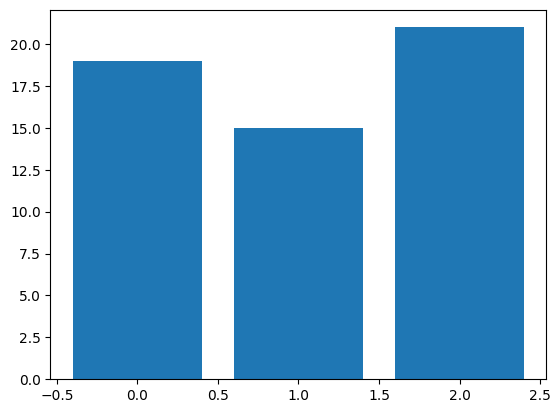

In [7]:
plt.bar(data["job"],data["education"])

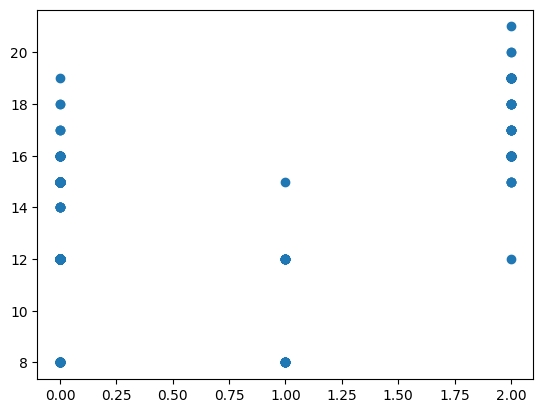

In [8]:
plt.scatter(data["job"],data["education"])

(array([363.,   0.,   0.,   0.,   0.,  27.,   0.,   0.,   0.,  84.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

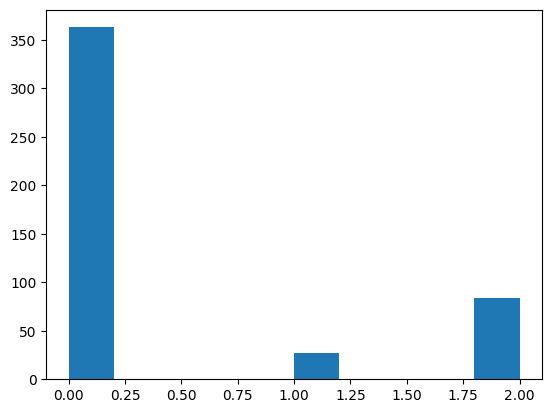

In [9]:
plt.hist(data["job"])

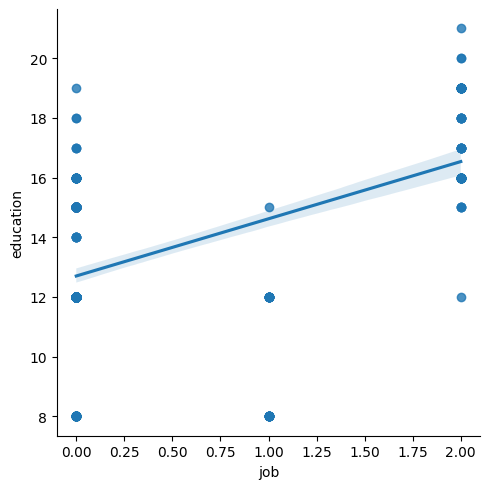

In [10]:
import seaborn as sns
sns.lmplot(x="job",y="education",data=data)


<Axes: xlabel='job', ylabel='gender'>

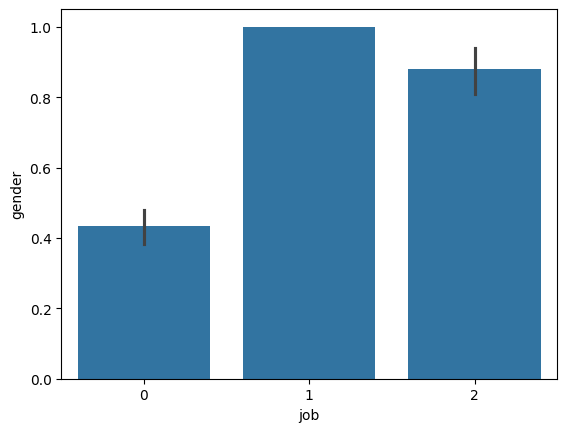

In [11]:
sns.barplot(x="job",y="gender",data=data)

<Axes: xlabel='job', ylabel='education'>

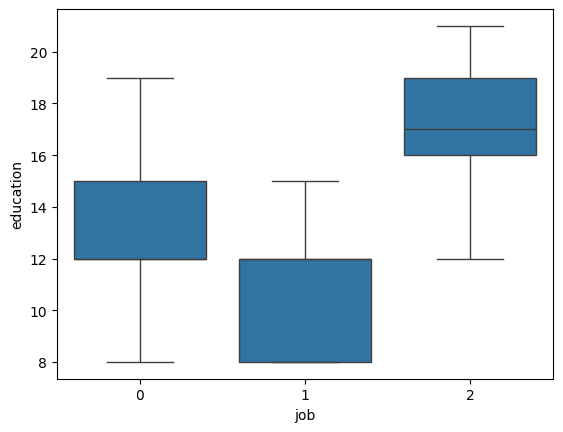

In [12]:
sns.boxplot(x="job",y="education",data=data)

<Axes: xlabel='job', ylabel='education'>

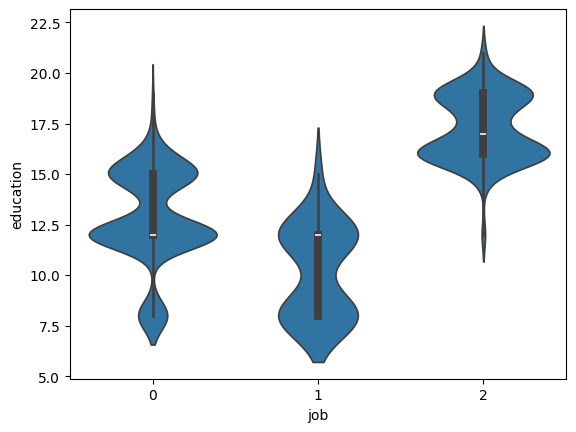

In [13]:
sns.violinplot(x="job",y="education",data=data)

<Axes: xlabel='job', ylabel='Density'>

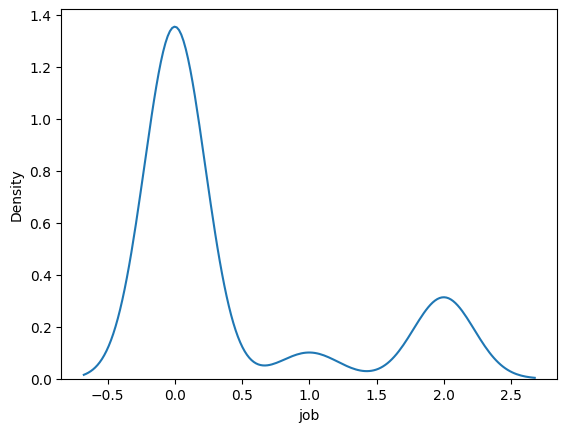

In [14]:
sns.kdeplot(x="job",data=data)

/tmp/ipython-input-15-2516169005.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["job"])


<Axes: xlabel='job', ylabel='Density'>

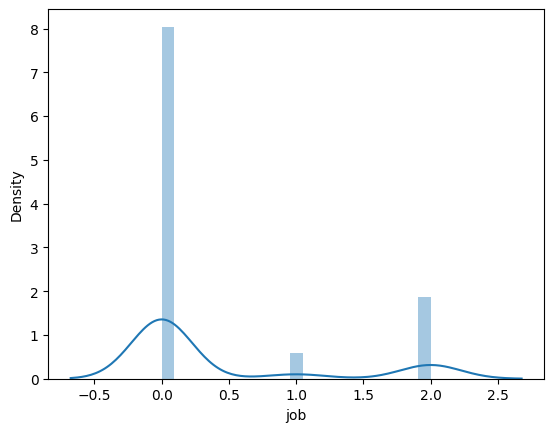

In [15]:
sns.distplot(data["job"])

<Axes: >

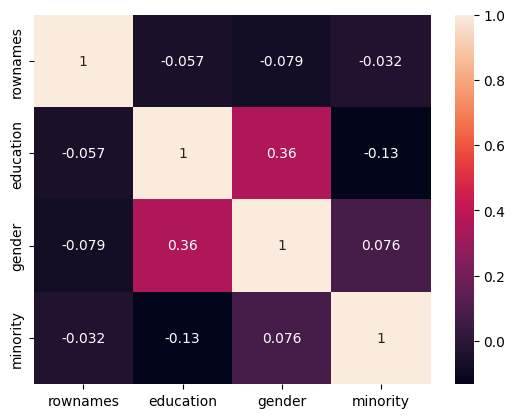

In [16]:
a=data.drop("job",axis=1).corr()
sns.heatmap(a,annot=True)

In [17]:
x=data.drop("job",axis=1)
y=data["job"]
print(x)

     rownames  education  gender  minority
0           1         15       1         0
1           2         16       1         0
2           3         12       0         0
3           4          8       0         0
4           5         15       1         0
..        ...        ...     ...       ...
469       470         12       1         1
470       471         15       1         1
471       472         15       1         0
472       473         12       0         0
473       474         12       0         0

[474 rows x 4 columns]


In [18]:
print(y)

0      2
1      0
2      0
3      0
4      0
      ..
469    0
470    0
471    0
472    0
473    0
Name: job, Length: 474, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [20]:
print(xtrain)

     rownames  education  gender  minority
85         86         15       1         0
57         58         15       0         0
426       427          8       1         1
178       179         12       1         1
418       419         15       1         0
..        ...        ...     ...       ...
314       315         12       0         0
343       344         12       1         0
49         50         16       1         0
438       439         12       0         0
281       282         14       1         1

[379 rows x 4 columns]


In [21]:
print(xtest)

     rownames  education  gender  minority
112       113         16       1         0
209       210         15       1         1
18         19         12       1         0
249       250         15       0         0
455       456         19       1         0
..        ...        ...     ...       ...
268       269         15       1         0
299       300         16       1         1
143       144          8       0         0
376       377         15       1         0
106       107         12       0         0

[95 rows x 4 columns]


In [22]:
print(ytrain)

85     0
57     0
426    0
178    0
418    0
      ..
314    0
343    0
49     2
438    0
281    0
Name: job, Length: 379, dtype: int64


In [23]:
print(ytest)

112    2
209    0
18     0
249    0
455    2
      ..
268    0
299    0
143    0
376    0
106    0
Name: job, Length: 95, dtype: int64


In [24]:
from sklearn.linear_model import LogisticRegression
b=LogisticRegression()
b.fit(xtrain,ytrain)
ypred=b.predict(xtest)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(ytest,ypred))

0.8210526315789474


In [26]:
a=b.predict([[1,15,1,0]])
print(a)

[0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [27]:
a=b.predict([[87,99,27,99]])
print(a)

[1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [28]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(ytest,ypred))

[[66  1  0]
 [ 5  3  0]
 [11  0  9]]


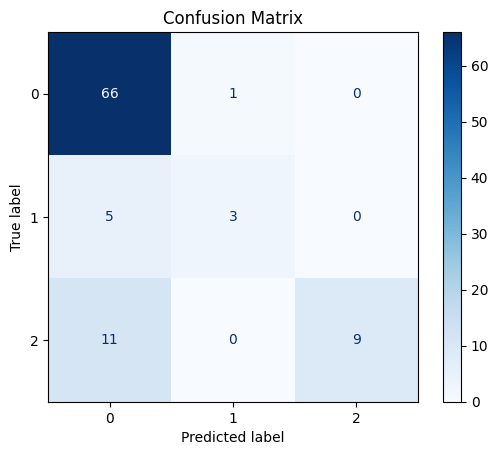

In [29]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Assuming ytest and ypred are defined
cm = confusion_matrix(ytest, ypred)
# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [30]:
from sklearn.metrics import classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89        67
           1       0.75      0.38      0.50         8
           2       1.00      0.45      0.62        20

    accuracy                           0.82        95
   macro avg       0.85      0.60      0.67        95
weighted avg       0.84      0.82      0.80        95

